<a href="https://colab.research.google.com/github/Limeng-svg/Grounded-PPE-Safety-Copilot/blob/main/notebooks/05b_resolve_leakage_and_create_group_split_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resolve Dataset Leakage and Build Split V2

This notebook:

1. Treats `construction_ppe_3class_v1` as read-only.
2. audits exact and perceptual duplicates across all images;
3. groups related images before splitting;
4. creates a new leakage-safe train/validation/test split;
5. does not train or evaluate any model.

The existing 12-image mini-eval set remains development-only.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime, timezone
from pandas.errors import EmptyDataError
import json

import pandas as pd

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Grounded-PPE-Safety-Copilot"
)

SOURCE_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "construction_ppe_3class_v1"
)

REPORT_ROOT = SOURCE_ROOT / "reports"

RUN_ID = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%S_%fZ")

RUN_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "leakage_resolution"
    / RUN_ID
)

RUN_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

SPLITS = ("train", "val", "test")

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
}

PHASH_AUTO_MAX_DISTANCE = 4
PHASH_REVIEW_MAX_DISTANCE = 8
EXPECTED_IMAGE_COUNT = 1416

assert SOURCE_ROOT.exists(), (
    f"Dataset not found: {SOURCE_ROOT}"
)

assert REPORT_ROOT.exists(), (
    f"Report directory not found: {REPORT_ROOT}"
)

assert (
    SOURCE_ROOT.resolve()
    not in RUN_ROOT.resolve().parents
), "RUN_ROOT must be outside the read-only v1 dataset."

print("Read-only source:", SOURCE_ROOT)
print("New output directory:", RUN_ROOT)

Mounted at /content/drive
Read-only source: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/datasets/construction_ppe_3class_v1
New output directory: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z


In [3]:
phash_path = (
    REPORT_ROOT
    / "perceptual_hashes.csv"
)

near_duplicate_path = (
    REPORT_ROOT
    / "cross_split_near_duplicates.csv"
)

legacy_overlap_path = (
    REPORT_ROOT
    / "legacy_overlap.csv"
)

for required_path in [
    phash_path,
    near_duplicate_path,
    legacy_overlap_path,
]:
    assert required_path.exists(), (
        f"Required file not found: {required_path}"
    )

phash_df = pd.read_csv(
    phash_path,
    dtype=str,
)

near_duplicate_df = pd.read_csv(
    near_duplicate_path,
)

try:
    legacy_overlap_df = pd.read_csv(
        legacy_overlap_path,
    )
except EmptyDataError:
    legacy_overlap_df = pd.DataFrame()

required_phash_columns = {
    "split",
    "image_name",
    "phash",
}

required_pair_columns = {
    "left_split",
    "left_image",
    "right_split",
    "right_image",
    "phash_distance",
    "decision",
}

assert required_phash_columns.issubset(
    phash_df.columns
), "perceptual_hashes.csv has unexpected columns."

assert required_pair_columns.issubset(
    near_duplicate_df.columns
), "cross_split_near_duplicates.csv has unexpected columns."

phash_df["split"] = (
    phash_df["split"]
    .str.strip()
)

phash_df["image_name"] = (
    phash_df["image_name"]
    .str.strip()
)

phash_df["phash"] = (
    phash_df["phash"]
    .str.strip()
    .str.lower()
)

phash_df["image_key"] = (
    phash_df["split"]
    + "/"
    + phash_df["image_name"]
)

assert len(phash_df) == EXPECTED_IMAGE_COUNT, (
    f"Expected {EXPECTED_IMAGE_COUNT} hash rows, "
    f"found {len(phash_df)}."
)

assert phash_df["image_key"].is_unique, (
    "Duplicate image keys were found."
)

assert phash_df["phash"].notna().all(), (
    "Missing pHash values were found."
)

assert phash_df["phash"].str.fullmatch(
    r"[0-9a-f]{16}"
).all(), "Invalid 64-bit hexadecimal pHash found."

assert set(phash_df["split"]) == set(SPLITS), (
    "Unexpected split names were found."
)

auto_group_count = int(
    (
        near_duplicate_df["decision"]
        == "AUTO_GROUP"
    ).sum()
)

manual_review_count = int(
    (
        near_duplicate_df["decision"]
        == "MANUAL_REVIEW"
    ).sum()
)

print("=== Existing audit inputs ===")
print("pHash records:", len(phash_df))
print(
    "Unique image keys:",
    phash_df["image_key"].nunique(),
)
print(
    "Cross-split AUTO_GROUP pairs:",
    auto_group_count,
)
print(
    "Cross-split MANUAL_REVIEW pairs:",
    manual_review_count,
)
print(
    "Legacy mini-eval overlap pairs:",
    len(legacy_overlap_df),
)

print("\n=== Records by original split ===")
print(
    phash_df["split"]
    .value_counts()
    .reindex(SPLITS)
)

=== Existing audit inputs ===
pHash records: 1416
Unique image keys: 1416
Cross-split AUTO_GROUP pairs: 38
Cross-split MANUAL_REVIEW pairs: 158
Legacy mini-eval overlap pairs: 0

=== Records by original split ===
split
train    1132
val       143
test      141
Name: count, dtype: int64


In [4]:
import hashlib
from tqdm.auto import tqdm

def file_sha256(file_path):
    digest = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        while True:
            chunk = file_handle.read(1024 * 1024)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def normalized_label_sha256(label_path):
    lines = []

    for raw_line in label_path.read_text(
        encoding="utf-8"
    ).splitlines():
        stripped_line = raw_line.strip()

        if stripped_line:
            lines.append(
                " ".join(stripped_line.split())
            )

    normalized_text = "\n".join(
        sorted(lines)
    )

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


manifest_records = []

for row in tqdm(
    phash_df.itertuples(index=False),
    total=len(phash_df),
    desc="Hashing images and labels",
):
    split_name = str(row.split)
    image_name = str(row.image_name)

    image_path = (
        SOURCE_ROOT
        / "images"
        / split_name
        / image_name
    )

    label_relative_path = (
        Path(image_name)
        .with_suffix(".txt")
    )

    label_path = (
        SOURCE_ROOT
        / "labels"
        / split_name
        / label_relative_path
    )

    assert image_path.is_file(), (
        f"Image not found: {image_path}"
    )

    assert label_path.is_file(), (
        f"Label not found: {label_path}"
    )

    manifest_records.append({
        "image_key": (
            f"{split_name}/"
            f"{Path(image_name).as_posix()}"
        ),
        "original_split": split_name,
        "image_name": image_name,
        "image_path": str(image_path),
        "label_path": str(label_path),
        "phash": str(row.phash),
        "image_sha256": file_sha256(
            image_path
        ),
        "label_sha256": file_sha256(
            label_path
        ),
        "normalized_label_sha256":
            normalized_label_sha256(
                label_path
            ),
    })

manifest_df = pd.DataFrame(
    manifest_records
).sort_values(
    "image_key"
).reset_index(drop=True)

assert len(manifest_df) == EXPECTED_IMAGE_COUNT
assert manifest_df["image_key"].is_unique
assert manifest_df["image_sha256"].notna().all()
assert manifest_df["label_sha256"].notna().all()

manifest_path = (
    RUN_ROOT / "input_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False,
)

sha_group_sizes = (
    manifest_df
    .groupby("image_sha256")
    .size()
)

sha_duplicate_group_count = int(
    (sha_group_sizes > 1).sum()
)

sha_duplicate_image_count = int(
    sha_group_sizes[
        sha_group_sizes > 1
    ].sum()
)

print("Manifest rows:", len(manifest_df))
print(
    "Unique image keys:",
    manifest_df["image_key"].nunique(),
)
print(
    "SHA duplicate groups:",
    sha_duplicate_group_count,
)
print(
    "Images in SHA duplicate groups:",
    sha_duplicate_image_count,
)
print("Manifest saved to:", manifest_path)

Hashing images and labels:   0%|          | 0/1416 [00:00<?, ?it/s]

Manifest rows: 1416
Unique image keys: 1416
SHA duplicate groups: 0
Images in SHA duplicate groups: 0
Manifest saved to: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z/input_manifest.csv


In [5]:
from collections import Counter

image_keys = (
    manifest_df["image_key"]
    .tolist()
)

original_splits = (
    manifest_df["original_split"]
    .tolist()
)

image_names = (
    manifest_df["image_name"]
    .tolist()
)

phash_integers = [
    int(value, 16)
    for value in manifest_df["phash"]
]

image_count = len(image_keys)

expected_comparisons = (
    image_count
    * (image_count - 1)
    // 2
)

assert expected_comparisons == 1_001_820

distance_histogram = Counter()
auto_edge_records = []
review_edge_records = []

comparison_count = 0

for left_index in tqdm(
    range(image_count - 1),
    desc="Comparing perceptual hashes",
):
    left_hash = phash_integers[
        left_index
    ]

    for right_index in range(
        left_index + 1,
        image_count,
    ):
        distance = (
            left_hash
            ^ phash_integers[right_index]
        ).bit_count()

        distance_histogram[distance] += 1
        comparison_count += 1

        if distance <= PHASH_AUTO_MAX_DISTANCE:
            auto_edge_records.append({
                "left_key":
                    image_keys[left_index],
                "right_key":
                    image_keys[right_index],
                "left_split":
                    original_splits[left_index],
                "right_split":
                    original_splits[right_index],
                "left_image":
                    image_names[left_index],
                "right_image":
                    image_names[right_index],
                "phash_distance": distance,
            })

        elif distance <= PHASH_REVIEW_MAX_DISTANCE:
            review_edge_records.append({
                "left_key":
                    image_keys[left_index],
                "right_key":
                    image_keys[right_index],
                "left_split":
                    original_splits[left_index],
                "right_split":
                    original_splits[right_index],
                "left_image":
                    image_names[left_index],
                "right_image":
                    image_names[right_index],
                "phash_distance": distance,
                "review_decision": "",
                "review_notes": "",
            })

assert comparison_count == expected_comparisons
assert sum(
    distance_histogram.values()
) == expected_comparisons

edge_columns = [
    "left_key",
    "right_key",
    "left_split",
    "right_split",
    "left_image",
    "right_image",
    "phash_distance",
]

review_columns = (
    edge_columns
    + [
        "review_decision",
        "review_notes",
    ]
)

auto_edges_df = pd.DataFrame(
    auto_edge_records,
    columns=edge_columns,
)

review_edges_df = pd.DataFrame(
    review_edge_records,
    columns=review_columns,
)

distance_histogram_df = pd.DataFrame([
    {
        "phash_distance": distance,
        "pair_count": pair_count,
    }
    for distance, pair_count
    in sorted(
        distance_histogram.items()
    )
])

auto_edges_path = (
    RUN_ROOT
    / "phash_auto_edges_le4.csv"
)

review_edges_path = (
    RUN_ROOT
    / "phash_review_edges_5_8_full.csv"
)

histogram_path = (
    RUN_ROOT
    / "distance_histogram.csv"
)

auto_edges_df.to_csv(
    auto_edges_path,
    index=False,
)

review_edges_df.to_csv(
    review_edges_path,
    index=False,
)

distance_histogram_df.to_csv(
    histogram_path,
    index=False,
)

cross_split_auto_count = int(
    (
        auto_edges_df["left_split"]
        != auto_edges_df["right_split"]
    ).sum()
)

cross_split_review_count = int(
    (
        review_edges_df["left_split"]
        != review_edges_df["right_split"]
    ).sum()
)

print("All-pairs comparisons:", comparison_count)
print(
    "All pHash distance <= 4 pairs:",
    len(auto_edges_df),
)
print(
    "Cross-split distance <= 4 pairs:",
    cross_split_auto_count,
)
print(
    "All pHash distance 5-8 pairs:",
    len(review_edges_df),
)
print(
    "Cross-split distance 5-8 pairs:",
    cross_split_review_count,
)
print("Results saved to:", RUN_ROOT)

Comparing perceptual hashes:   0%|          | 0/1415 [00:00<?, ?it/s]

All-pairs comparisons: 1001820
All pHash distance <= 4 pairs: 147
Cross-split distance <= 4 pairs: 38
All pHash distance 5-8 pairs: 504
Cross-split distance 5-8 pairs: 158
Results saved to: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z


In [6]:
from collections import defaultdict


class UnionFind:
    def __init__(self, items):
        self.parent = {
            item: item
            for item in items
        }

        self.rank = {
            item: 0
            for item in items
        }

    def find(self, item):
        if self.parent[item] != item:
            self.parent[item] = self.find(
                self.parent[item]
            )

        return self.parent[item]

    def union(self, left, right):
        left_root = self.find(left)
        right_root = self.find(right)

        if left_root == right_root:
            return

        if (
            self.rank[left_root]
            < self.rank[right_root]
        ):
            left_root, right_root = (
                right_root,
                left_root,
            )

        self.parent[right_root] = left_root

        if (
            self.rank[left_root]
            == self.rank[right_root]
        ):
            self.rank[left_root] += 1


image_keys = (
    manifest_df["image_key"]
    .tolist()
)

union_find = UnionFind(image_keys)

# Merge byte-identical images, if any.
for _, duplicate_group in (
    manifest_df
    .groupby("image_sha256")
):
    duplicate_keys = (
        duplicate_group["image_key"]
        .tolist()
    )

    for duplicate_key in duplicate_keys[1:]:
        union_find.union(
            duplicate_keys[0],
            duplicate_key,
        )

# Merge all high-confidence pHash pairs.
for row in auto_edges_df.itertuples(
    index=False
):
    union_find.union(
        row.left_key,
        row.right_key,
    )

members_by_root = defaultdict(list)

for image_key in image_keys:
    root = union_find.find(image_key)
    members_by_root[root].append(image_key)

sorted_components = sorted(
    [
        sorted(members)
        for members
        in members_by_root.values()
    ],
    key=lambda members: members[0],
)

split_by_key = dict(zip(
    manifest_df["image_key"],
    manifest_df["original_split"],
))

component_by_key = {}
component_summary_records = []

for component_index, members in enumerate(
    sorted_components
):
    component_text = "\n".join(members)

    component_digest = hashlib.sha256(
        component_text.encode("utf-8")
    ).hexdigest()[:12]

    component_id = (
        f"auto_{component_digest}"
    )

    original_component_splits = sorted({
        split_by_key[member]
        for member in members
    })

    for member in members:
        component_by_key[member] = (
            component_id
        )

    component_summary_records.append({
        "auto_component_id":
            component_id,
        "component_size":
            len(members),
        "original_splits":
            "|".join(
                original_component_splits
            ),
        "crosses_original_split":
            len(
                original_component_splits
            ) > 1,
        "representative_image_key":
            members[0],
    })

component_summary_df = pd.DataFrame(
    component_summary_records
)

component_members_df = (
    manifest_df
    .copy()
)

component_members_df[
    "auto_component_id"
] = component_members_df[
    "image_key"
].map(component_by_key)

component_size_by_id = dict(zip(
    component_summary_df[
        "auto_component_id"
    ],
    component_summary_df[
        "component_size"
    ],
))

component_members_df[
    "auto_component_size"
] = component_members_df[
    "auto_component_id"
].map(component_size_by_id)

assert (
    component_members_df[
        "auto_component_id"
    ].notna().all()
)

assert (
    component_summary_df[
        "component_size"
    ].sum()
    == EXPECTED_IMAGE_COUNT
)

# Add component IDs to the review edges.
review_with_components_df = (
    review_edges_df.copy()
)

review_with_components_df[
    "left_component_id"
] = review_with_components_df[
    "left_key"
].map(component_by_key)

review_with_components_df[
    "right_component_id"
] = review_with_components_df[
    "right_key"
].map(component_by_key)

assert review_with_components_df[
    "left_component_id"
].notna().all()

assert review_with_components_df[
    "right_component_id"
].notna().all()

review_with_components_df[
    "within_auto_component"
] = (
    review_with_components_df[
        "left_component_id"
    ]
    == review_with_components_df[
        "right_component_id"
    ]
)

internal_review_count = int(
    review_with_components_df[
        "within_auto_component"
    ].sum()
)

external_review_df = (
    review_with_components_df[
        ~review_with_components_df[
            "within_auto_component"
        ]
    ]
    .copy()
)

component_pairs = [
    tuple(sorted((left_id, right_id)))
    for left_id, right_id in zip(
        external_review_df[
            "left_component_id"
        ],
        external_review_df[
            "right_component_id"
        ],
    )
]

external_review_df[
    "component_a"
] = [
    pair[0]
    for pair in component_pairs
]

external_review_df[
    "component_b"
] = [
    pair[1]
    for pair in component_pairs
]

external_review_df[
    "cross_split_support"
] = (
    external_review_df["left_split"]
    != external_review_df["right_split"]
)

pair_statistics_df = (
    external_review_df
    .groupby(
        [
            "component_a",
            "component_b",
        ],
        as_index=False,
    )
    .agg(
        supporting_edge_count=(
            "phash_distance",
            "size",
        ),
        minimum_phash_distance=(
            "phash_distance",
            "min",
        ),
        maximum_phash_distance=(
            "phash_distance",
            "max",
        ),
        any_cross_split_support=(
            "cross_split_support",
            "max",
        ),
    )
)

representative_pairs_df = (
    external_review_df
    .sort_values([
        "component_a",
        "component_b",
        "phash_distance",
        "left_key",
        "right_key",
    ])
    .drop_duplicates([
        "component_a",
        "component_b",
    ])
)

reduced_review_df = (
    representative_pairs_df[
        [
            "component_a",
            "component_b",
            "left_key",
            "right_key",
            "left_split",
            "right_split",
            "left_image",
            "right_image",
            "phash_distance",
        ]
    ]
    .merge(
        pair_statistics_df,
        on=[
            "component_a",
            "component_b",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values([
        "minimum_phash_distance",
        "component_a",
        "component_b",
    ])
    .reset_index(drop=True)
)

reduced_review_df.insert(
    0,
    "review_pair_id",
    [
        f"review_{index:04d}"
        for index in range(
            1,
            len(reduced_review_df) + 1,
        )
    ],
)

reduced_review_df[
    "review_decision"
] = ""

reduced_review_df[
    "review_notes"
] = ""

component_members_path = (
    RUN_ROOT
    / "auto_component_members.csv"
)

component_summary_path = (
    RUN_ROOT
    / "auto_component_summary.csv"
)

full_review_path = (
    RUN_ROOT
    / "phash_review_edges_5_8_with_components.csv"
)

reduced_review_path = (
    RUN_ROOT
    / "phash_review_component_pairs_5_8.csv"
)

component_members_df.to_csv(
    component_members_path,
    index=False,
)

component_summary_df.to_csv(
    component_summary_path,
    index=False,
)

review_with_components_df.to_csv(
    full_review_path,
    index=False,
)

reduced_review_df.to_csv(
    reduced_review_path,
    index=False,
)

non_singleton_count = int(
    (
        component_summary_df[
            "component_size"
        ] > 1
    ).sum()
)

cross_split_component_count = int(
    component_summary_df[
        "crosses_original_split"
    ].sum()
)

largest_component_size = int(
    component_summary_df[
        "component_size"
    ].max()
)

print(
    "Total automatic components:",
    len(component_summary_df),
)

print(
    "Non-singleton automatic components:",
    non_singleton_count,
)

print(
    "Largest automatic component:",
    largest_component_size,
)

print(
    "Components crossing original splits:",
    cross_split_component_count,
)

print(
    "Review edges already inside automatic components:",
    internal_review_count,
)

print(
    "Remaining external review edges:",
    len(external_review_df),
)

print(
    "Unique component pairs requiring review:",
    len(reduced_review_df),
)

print(
    "Reduced review CSV:",
    reduced_review_path,
)

Total automatic components: 1300
Non-singleton automatic components: 62
Largest automatic component: 10
Components crossing original splits: 24
Review edges already inside automatic components: 84
Remaining external review edges: 420
Unique component pairs requiring review: 237
Reduced review CSV: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z/phash_review_component_pairs_5_8.csv


In [7]:
from PIL import (
    Image,
    ImageDraw,
    ImageFont,
)
from pathlib import Path
from tqdm.auto import tqdm


PAIR_PREVIEW_ROOT = (
    RUN_ROOT / "pair_previews"
)

PAIR_PREVIEW_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

image_path_by_key = dict(zip(
    component_members_df["image_key"],
    component_members_df["image_path"],
))

font_path = Path(
    "/usr/share/fonts/truetype/"
    "dejavu/DejaVuSans.ttf"
)

if font_path.exists():
    title_font = ImageFont.truetype(
        str(font_path),
        22,
    )

    label_font = ImageFont.truetype(
        str(font_path),
        17,
    )
else:
    title_font = ImageFont.load_default()
    label_font = ImageFont.load_default()


def create_contained_image(
    image_path,
    target_size,
):
    with Image.open(image_path) as source:
        source = source.convert("RGB")
        source.thumbnail(
            target_size,
            Image.Resampling.LANCZOS,
        )

        canvas = Image.new(
            "RGB",
            target_size,
            "white",
        )

        paste_x = (
            target_size[0] - source.width
        ) // 2

        paste_y = (
            target_size[1] - source.height
        ) // 2

        canvas.paste(
            source,
            (paste_x, paste_y),
        )

    return canvas


PANEL_WIDTH = 420
PANEL_HEIGHT = 320
HEADER_HEIGHT = 100
MARGIN = 18
GAP = 18

PAIR_WIDTH = (
    PANEL_WIDTH * 2
    + GAP
    + MARGIN * 2
)

PAIR_HEIGHT = (
    HEADER_HEIGHT
    + PANEL_HEIGHT
    + MARGIN * 2
)

review_output_df = (
    reduced_review_df.copy()
)

preview_paths = []

for row in tqdm(
    review_output_df.itertuples(
        index=False
    ),
    total=len(review_output_df),
    desc="Creating pair previews",
):
    left_image_path = Path(
        image_path_by_key[row.left_key]
    )

    right_image_path = Path(
        image_path_by_key[row.right_key]
    )

    assert left_image_path.is_file()
    assert right_image_path.is_file()

    left_panel = create_contained_image(
        left_image_path,
        (PANEL_WIDTH, PANEL_HEIGHT),
    )

    right_panel = create_contained_image(
        right_image_path,
        (PANEL_WIDTH, PANEL_HEIGHT),
    )

    pair_canvas = Image.new(
        "RGB",
        (PAIR_WIDTH, PAIR_HEIGHT),
        (245, 245, 245),
    )

    draw = ImageDraw.Draw(pair_canvas)

    title_text = (
        f"{row.review_pair_id}    "
        f"pHash distance: "
        f"{row.phash_distance}    "
        f"supporting edges: "
        f"{row.supporting_edge_count}"
    )

    draw.text(
        (MARGIN, 12),
        title_text,
        fill="black",
        font=title_font,
    )

    draw.text(
        (MARGIN, 52),
        f"LEFT: {row.left_key}",
        fill=(20, 60, 150),
        font=label_font,
    )

    right_text_x = (
        MARGIN
        + PANEL_WIDTH
        + GAP
    )

    draw.text(
        (right_text_x, 52),
        f"RIGHT: {row.right_key}",
        fill=(150, 45, 30),
        font=label_font,
    )

    image_y = HEADER_HEIGHT

    pair_canvas.paste(
        left_panel,
        (MARGIN, image_y),
    )

    pair_canvas.paste(
        right_panel,
        (right_text_x, image_y),
    )

    preview_path = (
        PAIR_PREVIEW_ROOT
        / f"{row.review_pair_id}.jpg"
    )

    pair_canvas.save(
        preview_path,
        quality=92,
    )

    preview_paths.append(
        str(preview_path)
    )

review_output_df[
    "pair_preview_path"
] = preview_paths

review_output_df[
    "allowed_decisions"
] = (
    "SAME_SCENE|"
    "DIFFERENT_SCENE|"
    "UNCERTAIN"
)

review_output_df[
    "review_decision"
] = ""

review_output_df[
    "review_notes"
] = ""

print(
    "Pair previews created:",
    len(preview_paths),
)

print(
    "Pair preview directory:",
    PAIR_PREVIEW_ROOT,
)

Creating pair previews:   0%|          | 0/237 [00:00<?, ?it/s]

Pair previews created: 237
Pair preview directory: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z/pair_previews


Review pairs: 237
Contact sheets: 30
Review CSV: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z/review_decisions_template.csv
Review bundle: /content/drive/MyDrive/Grounded-PPE-Safety-Copilot/outputs/leakage_resolution/20260911T131708_088769Z_pair_review_bundle.zip

First two contact sheets:


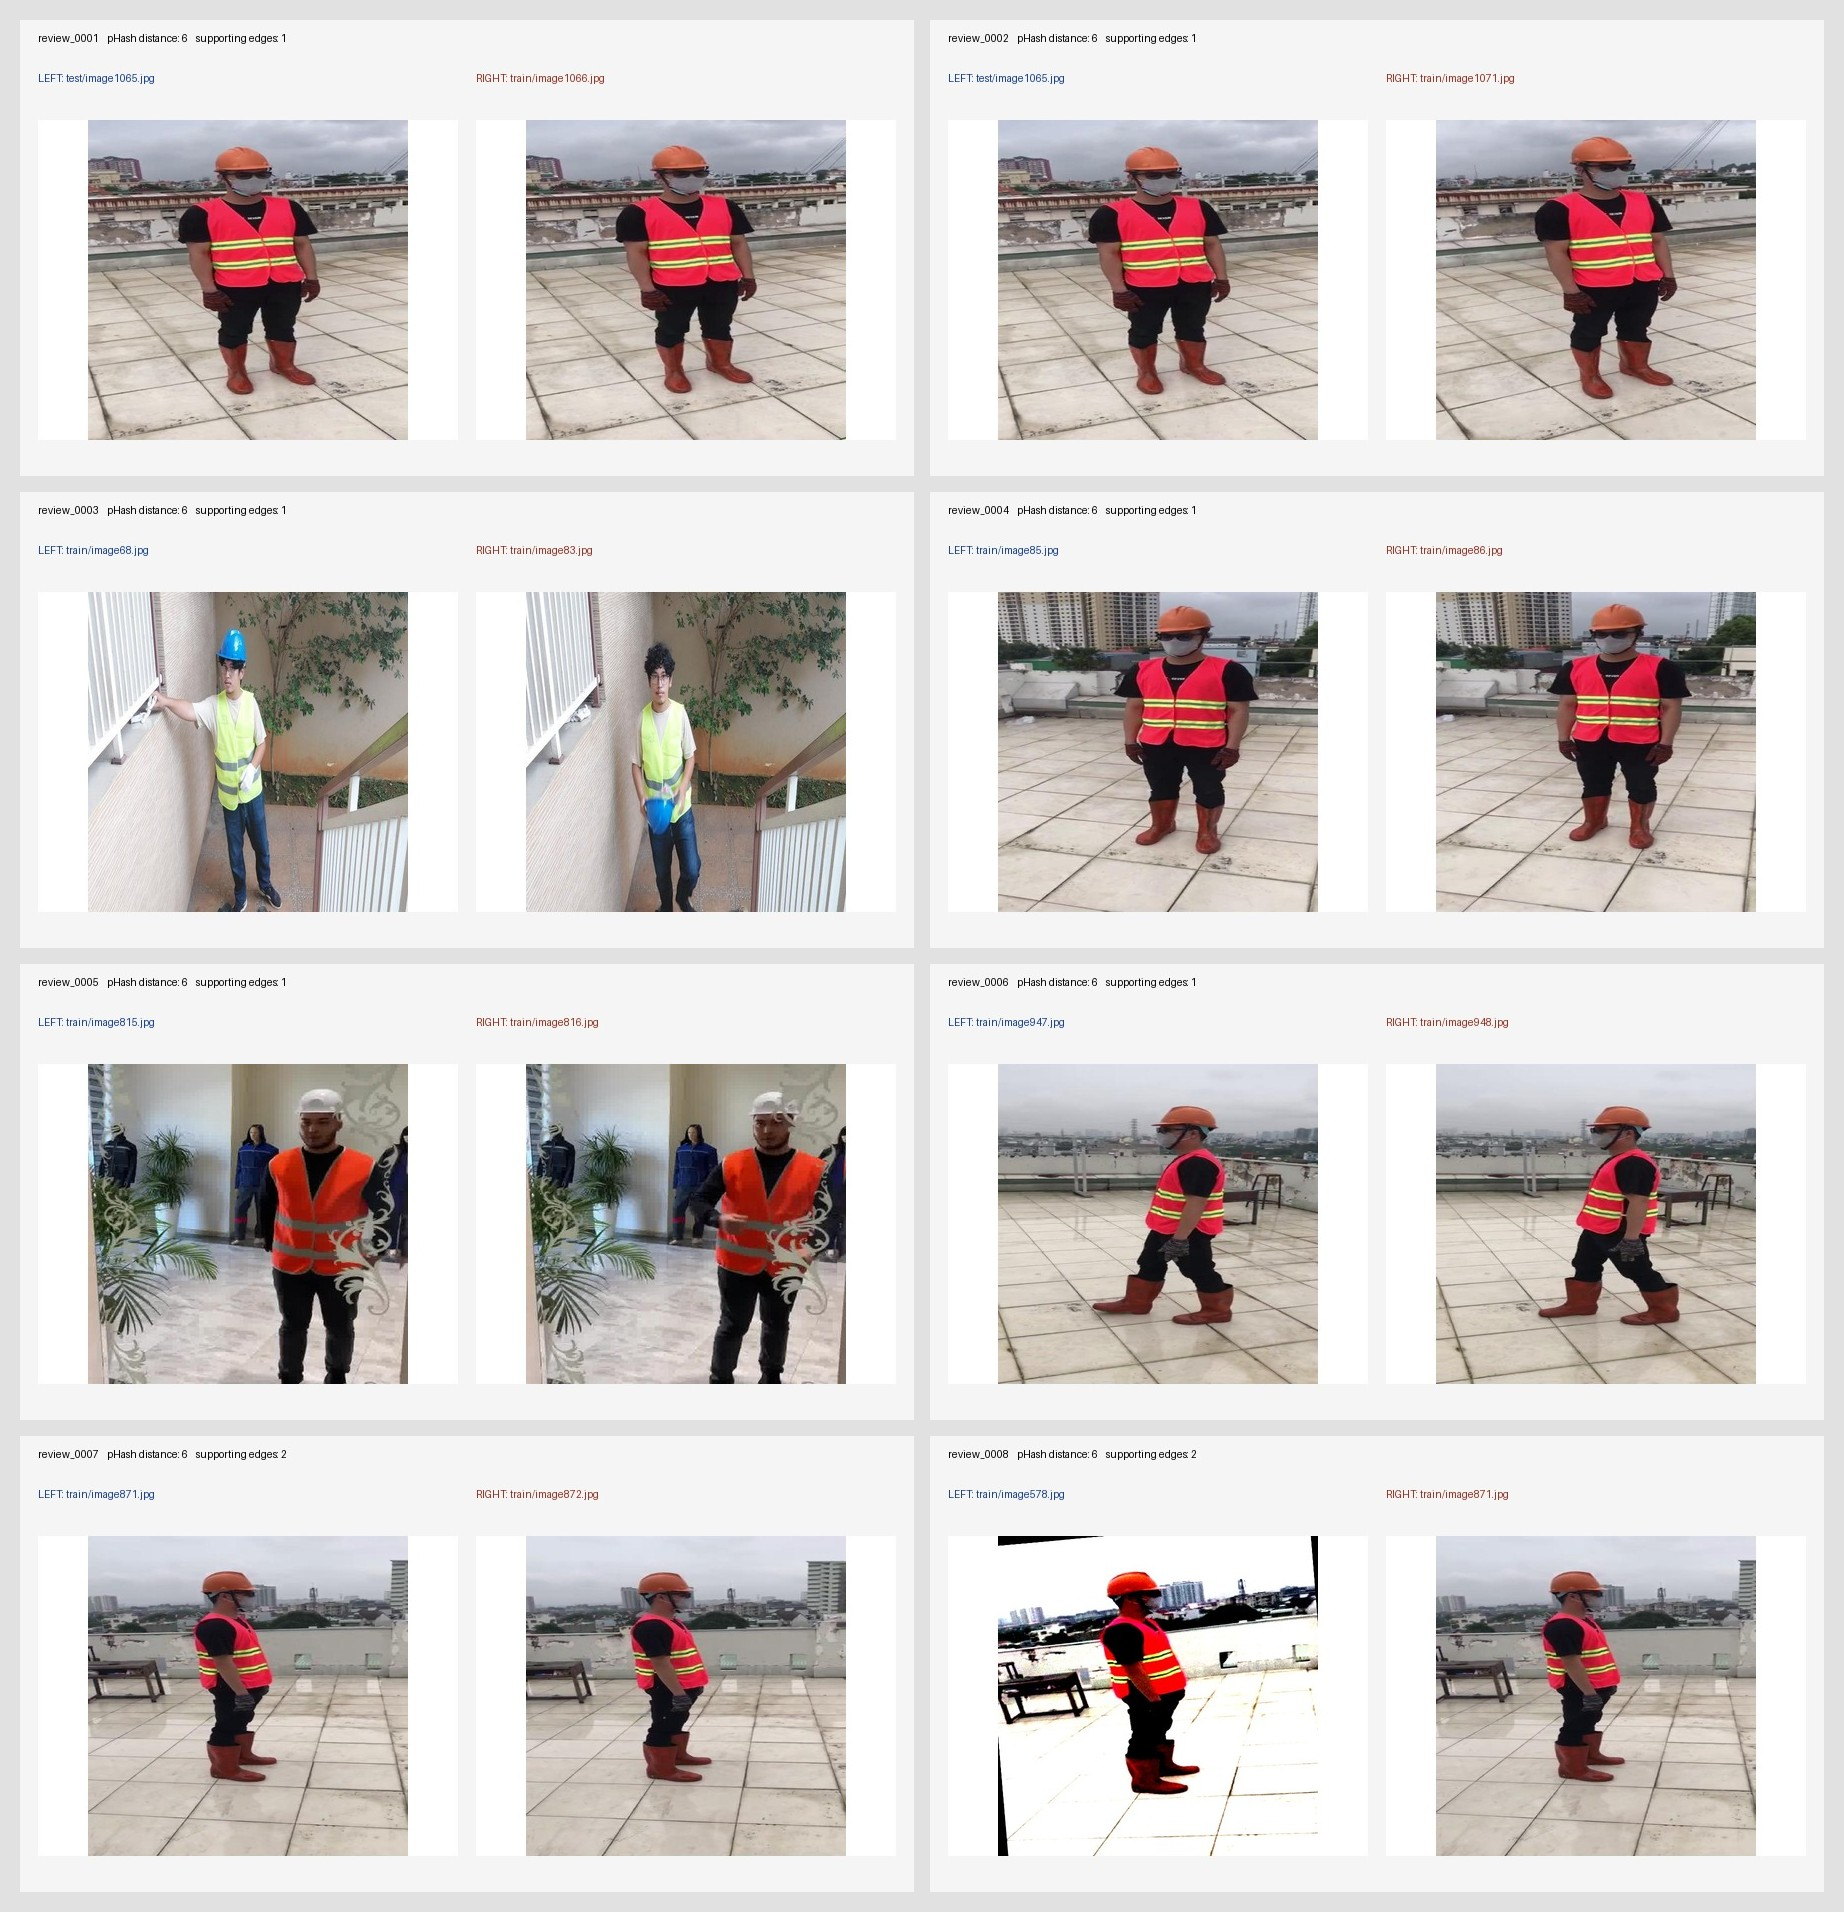

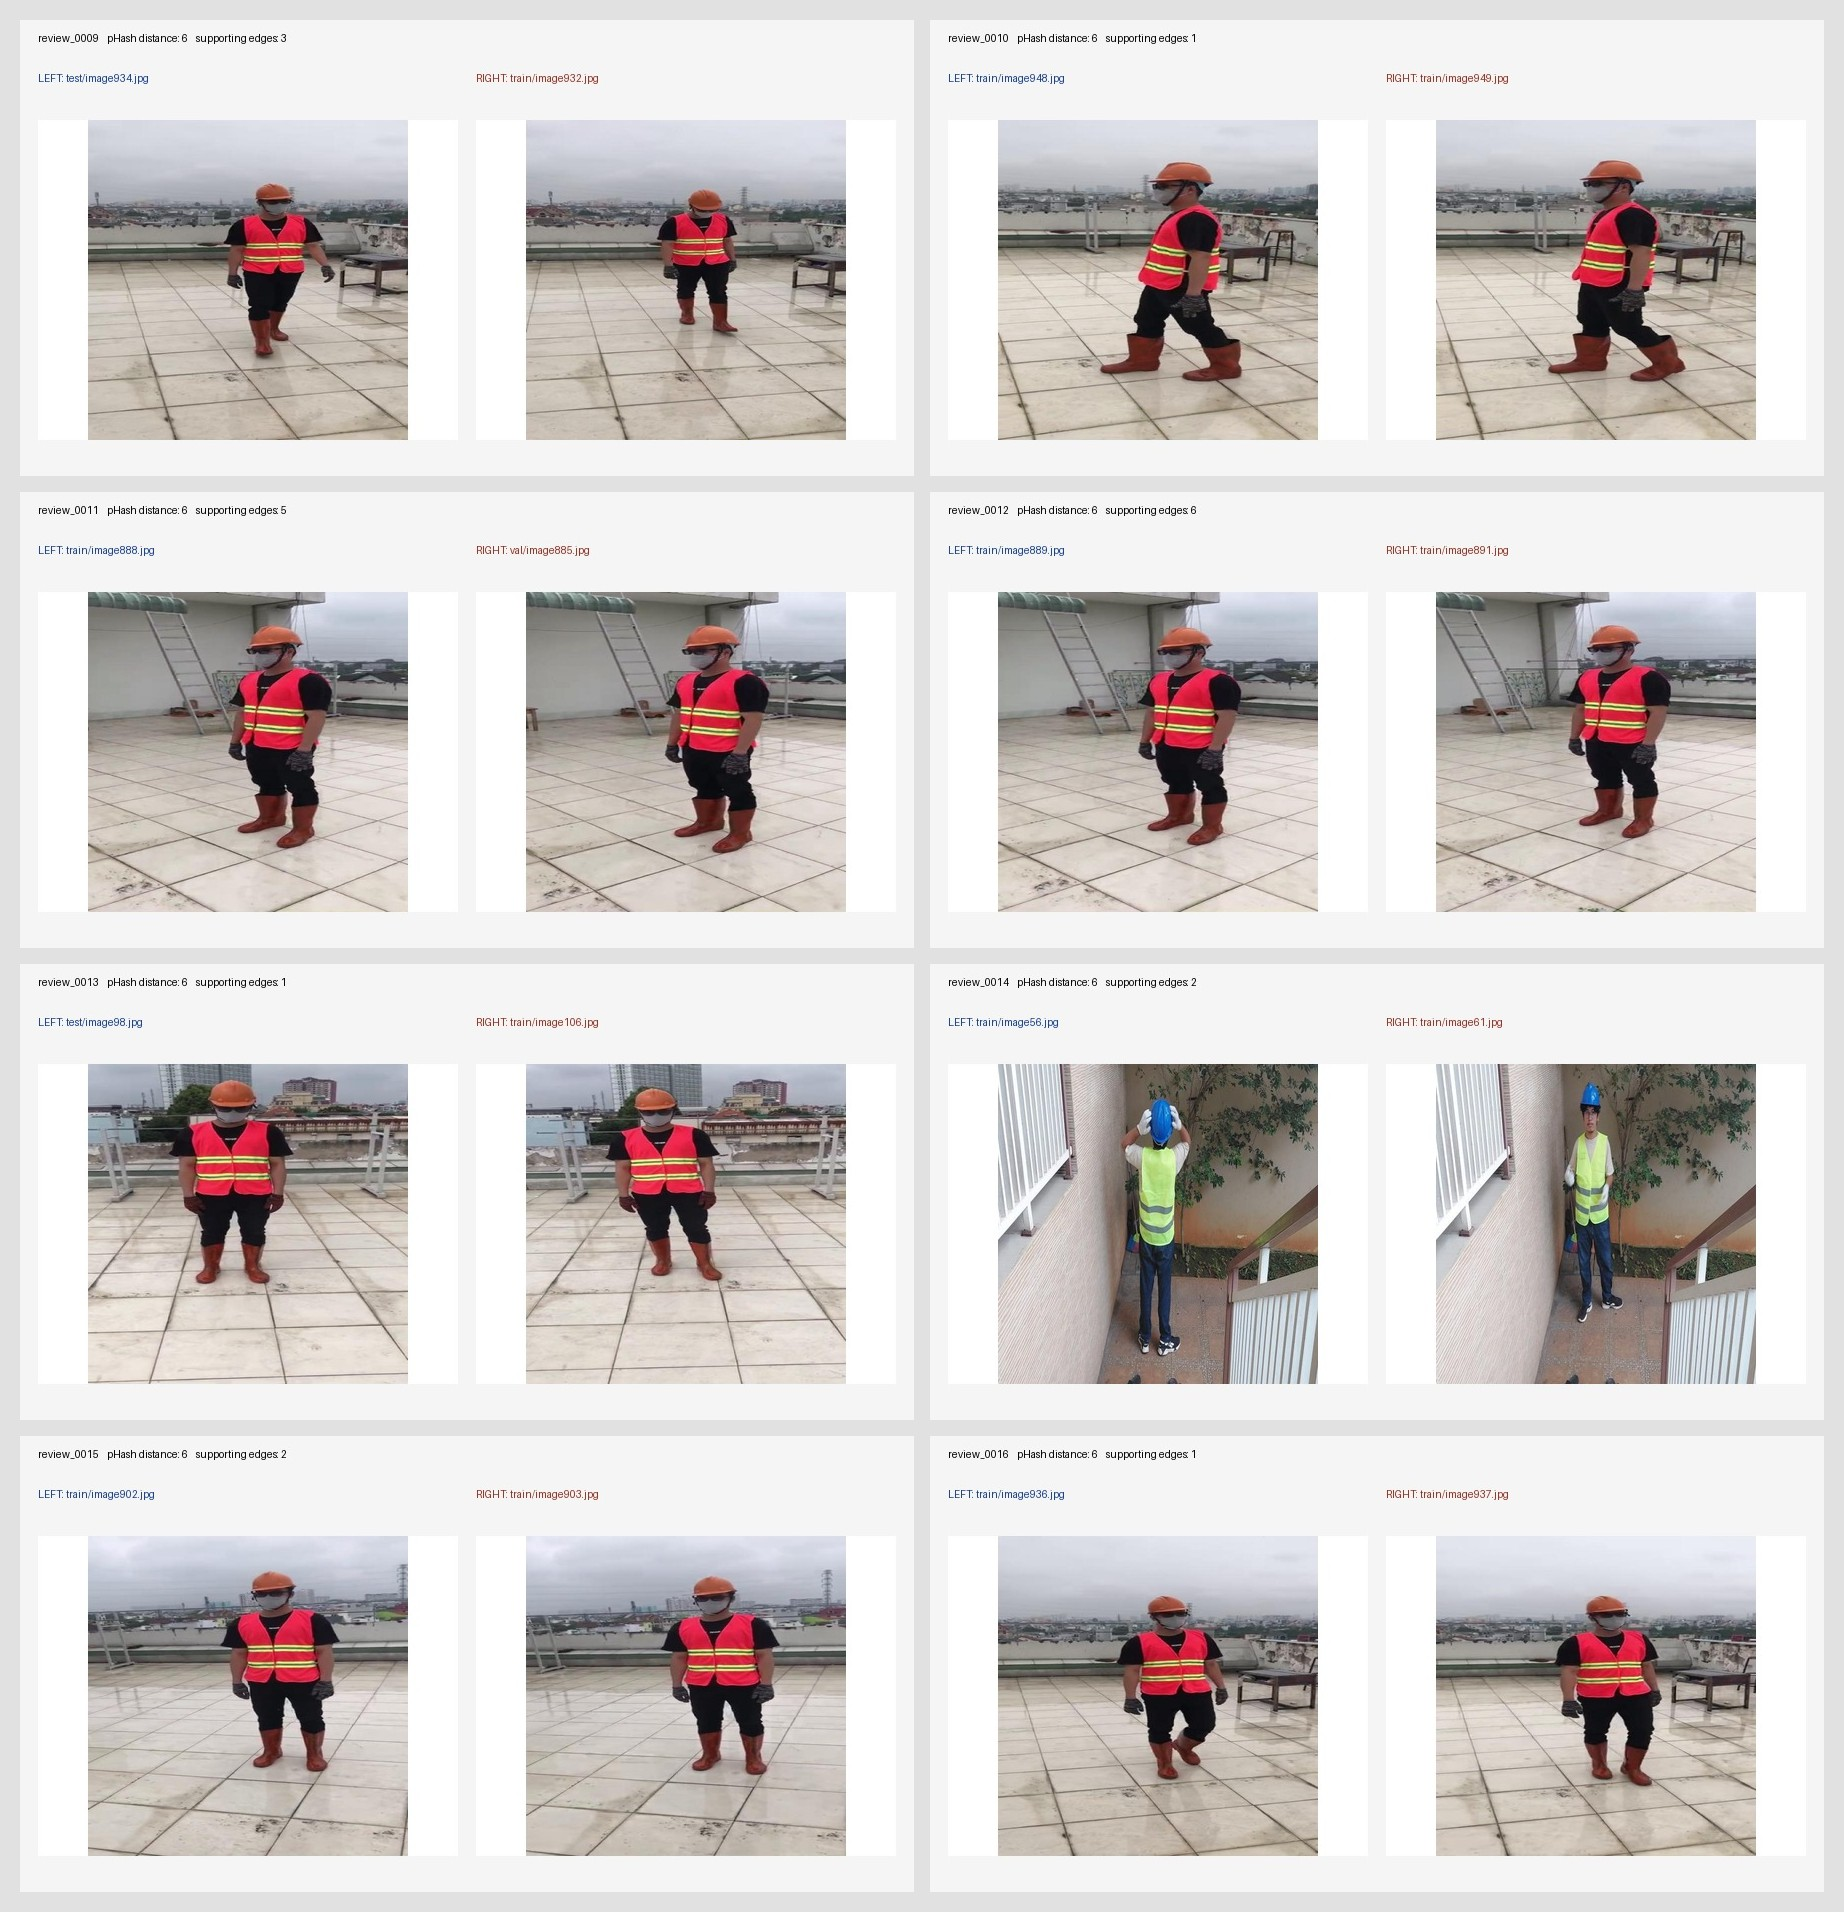

In [8]:
import math
import zipfile

from IPython.display import display


CONTACT_SHEET_ROOT = (
    RUN_ROOT / "contact_sheets"
)

CONTACT_SHEET_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SHEET_COLUMNS = 2
SHEET_ROWS = 4
PAIRS_PER_SHEET = (
    SHEET_COLUMNS * SHEET_ROWS
)

SHEET_MARGIN = 20
SHEET_GAP = 16

sheet_width = (
    PAIR_WIDTH * SHEET_COLUMNS
    + SHEET_GAP * (
        SHEET_COLUMNS - 1
    )
    + SHEET_MARGIN * 2
)

sheet_height = (
    PAIR_HEIGHT * SHEET_ROWS
    + SHEET_GAP * (
        SHEET_ROWS - 1
    )
    + SHEET_MARGIN * 2
)

sheet_assignments = {}
contact_sheet_paths = []

sheet_count = math.ceil(
    len(review_output_df)
    / PAIRS_PER_SHEET
)

for sheet_index in range(sheet_count):
    sheet_canvas = Image.new(
        "RGB",
        (sheet_width, sheet_height),
        (225, 225, 225),
    )

    first_index = (
        sheet_index
        * PAIRS_PER_SHEET
    )

    last_index = min(
        first_index + PAIRS_PER_SHEET,
        len(review_output_df),
    )

    for dataframe_index in range(
        first_index,
        last_index,
    ):
        local_index = (
            dataframe_index
            - first_index
        )

        grid_row = (
            local_index
            // SHEET_COLUMNS
        )

        grid_column = (
            local_index
            % SHEET_COLUMNS
        )

        pair_record = (
            review_output_df
            .iloc[dataframe_index]
        )

        pair_preview_path = Path(
            pair_record[
                "pair_preview_path"
            ]
        )

        with Image.open(
            pair_preview_path
        ) as pair_preview:
            pair_preview = (
                pair_preview
                .convert("RGB")
            )

            paste_x = (
                SHEET_MARGIN
                + grid_column
                * (
                    PAIR_WIDTH
                    + SHEET_GAP
                )
            )

            paste_y = (
                SHEET_MARGIN
                + grid_row
                * (
                    PAIR_HEIGHT
                    + SHEET_GAP
                )
            )

            sheet_canvas.paste(
                pair_preview,
                (paste_x, paste_y),
            )

        review_pair_id = pair_record[
            "review_pair_id"
        ]

        sheet_assignments[
            review_pair_id
        ] = {
            "contact_sheet":
                f"contact_sheet_"
                f"{sheet_index + 1:03d}.jpg",
            "position_on_sheet":
                f"row_{grid_row + 1}_"
                f"column_{grid_column + 1}",
        }

    contact_sheet_path = (
        CONTACT_SHEET_ROOT
        / (
            f"contact_sheet_"
            f"{sheet_index + 1:03d}.jpg"
        )
    )

    sheet_canvas.save(
        contact_sheet_path,
        quality=90,
    )

    contact_sheet_paths.append(
        contact_sheet_path
    )

review_output_df[
    "contact_sheet"
] = review_output_df[
    "review_pair_id"
].map(
    lambda pair_id:
        sheet_assignments[
            pair_id
        ]["contact_sheet"]
)

review_output_df[
    "position_on_sheet"
] = review_output_df[
    "review_pair_id"
].map(
    lambda pair_id:
        sheet_assignments[
            pair_id
        ]["position_on_sheet"]
)

review_csv_path = (
    RUN_ROOT
    / "review_decisions_template.csv"
)

review_output_df.to_csv(
    review_csv_path,
    index=False,
)

bundle_path = (
    RUN_ROOT.parent
    / (
        f"{RUN_ROOT.name}_"
        f"pair_review_bundle.zip"
    )
)

with zipfile.ZipFile(
    bundle_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    archive.write(
        review_csv_path,
        arcname=review_csv_path.name,
    )

    for preview_path in (
        PAIR_PREVIEW_ROOT.glob("*.jpg")
    ):
        archive.write(
            preview_path,
            arcname=(
                "pair_previews/"
                + preview_path.name
            ),
        )

    for sheet_path in contact_sheet_paths:
        archive.write(
            sheet_path,
            arcname=(
                "contact_sheets/"
                + sheet_path.name
            ),
        )

print(
    "Review pairs:",
    len(review_output_df),
)

print(
    "Contact sheets:",
    len(contact_sheet_paths),
)

print(
    "Review CSV:",
    review_csv_path,
)

print(
    "Review bundle:",
    bundle_path,
)

print(
    "\nFirst two contact sheets:"
)

for sheet_path in (
    contact_sheet_paths[:2]
):
    display(
        Image.open(sheet_path)
    )